<a href="https://colab.research.google.com/github/adhora7/KMeans-Segmentation-of-Customers/blob/main/Kmeans_Segmentation_of_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

Data Analysis

In [ ]:
customer_data =  pd.read_csv('Mall_Customers.csv')


In [ ]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X = customer_data.iloc[:,[3,4]].values

In [ ]:
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Number of clusters choosing

In [ ]:
wcss = []
silhouette = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, model.labels_))

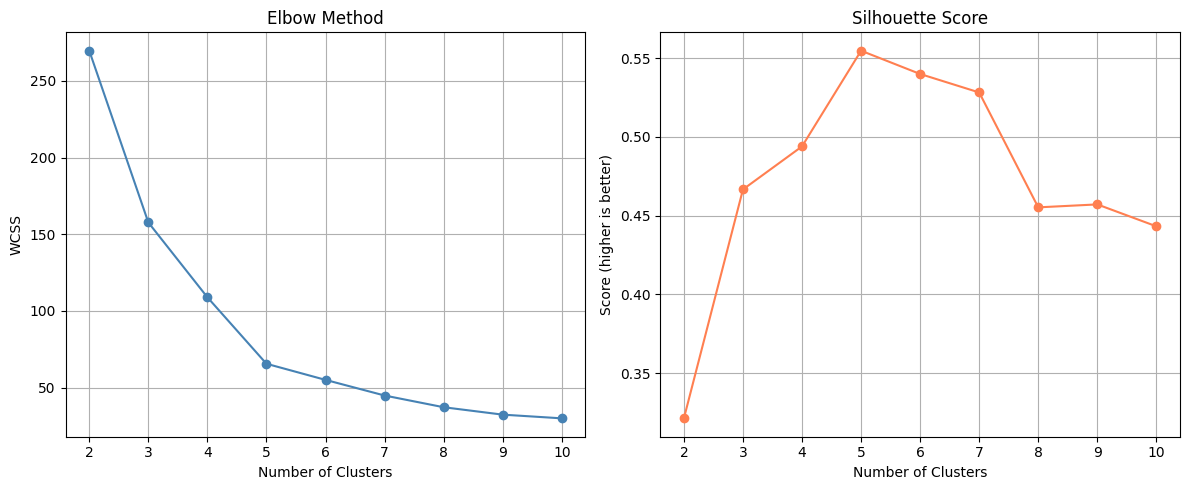

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o', color='steelblue')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette, marker='o', color='coral')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score (higher is better)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
best_k = silhouette.index(max(silhouette)) + 2
print(f"\nBest number of clusters: {best_k}")


Best number of clusters: 5


Optimum number of clusters =5                                                         
Training the Kmeans Clustering model

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
customer_data['Cluster'] = labels
print("\nCustomers per cluster:")
print(customer_data['Cluster'].value_counts().sort_index())



Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64




Visualizing all the clusters

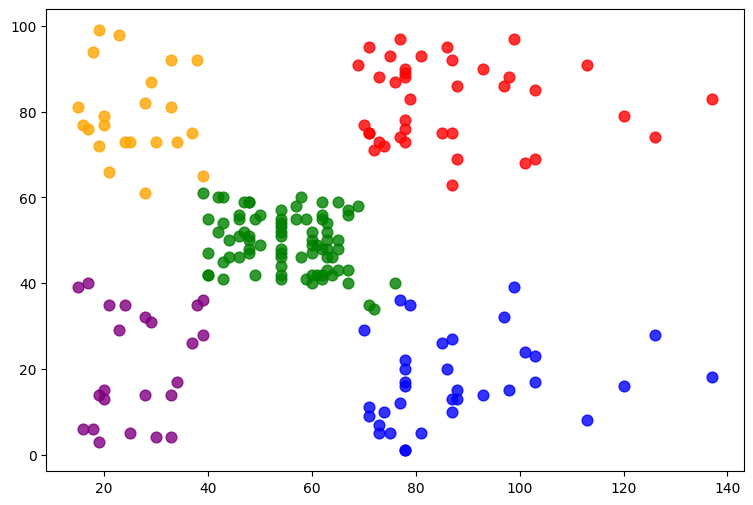

In [ ]:
colors = ['green', 'red', 'orange', 'blue', 'purple']

plt.figure(figsize=(9, 6))

for i in range(5):
    points = X[labels == i]
    plt.scatter(points[:, 0], points[:, 1],
                s=60, c=colors[i], label=f'Cluster {i+1}', alpha=0.8)

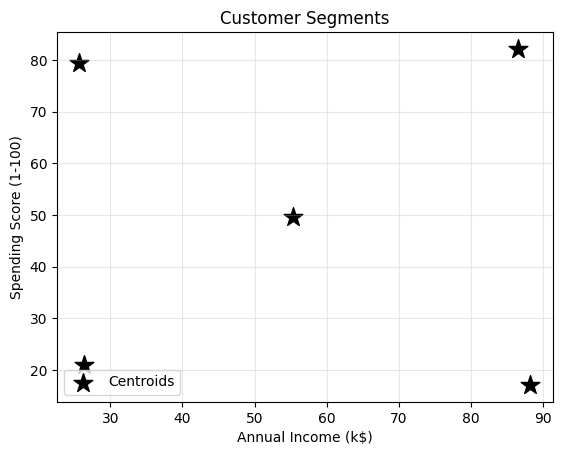

In [ ]:
# Plot centroids (convert back from scaled to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='black', marker='*', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Understanding each cluster

In [ ]:
print("\n" + "="*50)
print("CLUSTER SUMMARY")
print("="*50)

summary = customer_data.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
summary['Total Customers'] = customer_data.groupby('Cluster').size()
print(summary)

print("""
What each group likely means:
  Cluster with High Income + High Spending  → VIP Customers
  Cluster with High Income + Low Spending   → Careful Spenders
  Cluster with Low Income  + High Spending  → Impulsive Buyers
  Cluster with Low Income  + Low Spending   → Budget Customers
  Cluster with Mid Income  + Mid Spending   → Average Customers
""")


CLUSTER SUMMARY
          Age  Annual Income (k$)  Spending Score (1-100)  Total Customers
Cluster                                                                   
0        42.7                55.3                    49.5               81
1        32.7                86.5                    82.1               39
2        25.3                25.7                    79.4               22
3        41.1                88.2                    17.1               35
4        45.2                26.3                    20.9               23

What each group likely means:
  Cluster with High Income + High Spending  → VIP Customers
  Cluster with High Income + Low Spending   → Careful Spenders
  Cluster with Low Income  + High Spending  → Impulsive Buyers
  Cluster with Low Income  + Low Spending   → Budget Customers
  Cluster with Mid Income  + Mid Spending   → Average Customers

